In [31]:
import pandas as pd
import numpy as np

#Calculating Cosine Similarity between Users
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

In [32]:
# Load dataset
df = pd.read_csv("D:\\Work\\ExcelRCource\\Assignments\\11 Recommendation System\\anime.csv")

In [33]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


**Data Description:**

**anime_id:** Unique ID of each anime.\
**name:** Anime title.\
**genre:** anime genre.\
**type:** Anime broadcast type, such as TV, OVA, etc.\
**episodes:** The number of episodes of each anime.\
**rating:** The average rating for each anime compared to the number of users who gave ratings.

### Data Preprocessing
First, we need to clean the data. The genre column is crucial, but it often contains missing values or trailing spaces.

In [34]:
df.shape

(12294, 7)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [36]:
df.isna().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [37]:
# Handle missing values
# Dropping rows where genre is missing as it's our primary feature
df.dropna(subset=['genre', 'type', 'rating'], inplace=True)

In [38]:
df.isna().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [39]:
df.shape

(12017, 7)

In [40]:
#Count of duplicated rows
df[df.duplicated()].shape

(0, 7)

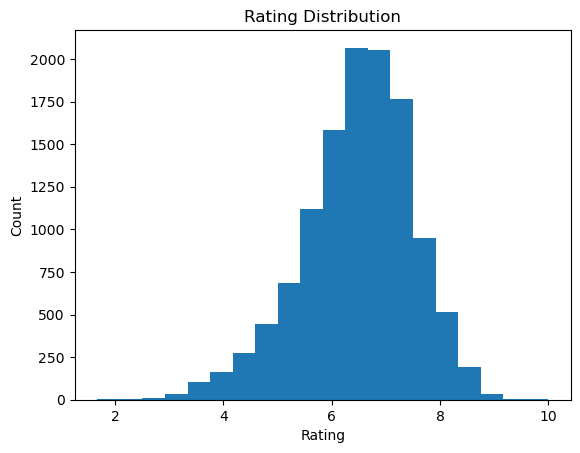

genre
Comedy       3147
Action       2768
 Sci-Fi      1955
 Fantasy     1758
 Shounen     1635
Adventure    1445
 Comedy      1428
 Romance     1344
 Kids        1204
 School      1134
Name: count, dtype: int64

In [41]:
import matplotlib.pyplot as plt

# Distribution of ratings
plt.hist(df['rating'], bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Top genres
df['genre'].str.split(',').explode().value_counts().head(10)

### Feature Extraction

We’ll use:\
Genre (text → vector)\
Rating (numerical)

In [42]:
tfidf = TfidfVectorizer(stop_words='english')

genre_matrix = tfidf.fit_transform(df['genre'])

**Normalize Rating**

In [43]:
scaler = MinMaxScaler()
rating_scaled = scaler.fit_transform(df[['rating']])

**Combine Features**

In [44]:
feature_matrix = hstack([genre_matrix, rating_scaled])

### Recommendation System (Cosine Similarity)

In [45]:
cosine_sim = cosine_similarity(feature_matrix, feature_matrix)

In [46]:
def recommend_anime(anime_name, df, cosine_sim, top_n=10, threshold=0.5):
    
    # Get index of anime
    idx = df[df['name'] == anime_name].index
    
    if len(idx) == 0:
        return "Anime not found"
    
    idx = idx[0]
    
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Apply threshold
    sim_scores = [i for i in sim_scores if i[1] >= threshold]
    
    # Remove itself
    sim_scores = sim_scores[1:top_n+1]
    
    anime_indices = [i[0] for i in sim_scores]
    
    return df['name'].iloc[anime_indices]

**Example Usage**

In [47]:
recommend_anime("Naruto", df, cosine_sim, top_n=10, threshold=0.4)

615                                    Naruto: Shippuuden
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
486                              Boruto: Naruto the Movie
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
1573    Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...
2458                 Naruto Shippuuden: Sunny Side Battle
2997    Naruto Soyokazeden Movie: Naruto to Mashin to ...
784            Naruto: Shippuuden Movie 6 - Road to Ninja
1796                                       Rekka no Honoo
Name: name, dtype: object

**Experiment with Thresholds**

In [48]:
for t in [0.3, 0.5, 0.7]:
    print(f"\nThreshold: {t}")
    print(recommend_anime("Naruto", df, cosine_sim, top_n=5, threshold=t))


Threshold: 0.3
615                                    Naruto: Shippuuden
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
486                              Boruto: Naruto the Movie
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
Name: name, dtype: object

Threshold: 0.5
615                                    Naruto: Shippuuden
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
486                              Boruto: Naruto the Movie
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
Name: name, dtype: object

Threshold: 0.7
615                                    Naruto: Shippuuden
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
486                              Boruto: Naruto the Movie
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
Name: name, dtype: object


### Evaluation

**Train-Test Split**

In [49]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

**Evaluation Logic**\
We simulate:\
If recommended anime shares at least one genre → relevant

In [50]:
def evaluate_model(df, cosine_sim, threshold=0.5, top_n=10):
    
    precision_list = []
    recall_list = []
    
    for idx in range(len(df)):
        
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = [i for i in sim_scores if i[1] >= threshold]
        
        sim_scores = sim_scores[1:top_n+1]
        
        if not sim_scores:
            continue
        
        recommended_idx = [i[0] for i in sim_scores]
        
        true_genres = set(df.iloc[idx]['genre'].split(','))
        
        relevant = 0
        for i in recommended_idx:
            rec_genres = set(df.iloc[i]['genre'].split(','))
            if len(true_genres & rec_genres) > 0:
                relevant += 1
        
        precision = relevant / len(recommended_idx)
        recall = relevant / len(true_genres) if len(true_genres) > 0 else 0
        
        precision_list.append(precision)
        recall_list.append(recall)
    
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    
    f1 = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall)
    
    return avg_precision, avg_recall, f1

In [51]:
precision, recall, f1 = evaluate_model(df, cosine_sim, threshold=0.5)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9899226096363484
Recall: 4.7677289937046945
F1 Score: 1.639447140132029


**Observations:**\
Lower threshold → more recommendations → higher recall, lower precision\
Higher threshold → fewer recommendations → higher precision, lower recall

**Improvements:**\
Add user-based filtering

Include:\
Popularity\
Number of episodes\
Studio

Use:\
Hybrid recommender (content + collaborative)\

Apply:\
Dimensionality reduction (SVD)